# NYC Spatial Analysis with GeoPandas

**Lesson 2.5 — Python Analysis**

This notebook loads the same NYC datasets from Lesson 2.2 (neighborhoods and fire hydrants),
explores them with GeoPandas, performs spatial analysis, and exports the results.

**What you'll learn:**
- Loading GeoJSON into GeoDataFrames
- Inspecting geometry types, CRS, and basic statistics
- Plotting spatial data with matplotlib
- Spatial joins (points in polygons)
- Exporting results to GeoParquet

## 1. Setup and Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import psycopg
import os

# Display all columns in DataFrames
pd.set_option('display.max_columns', None)

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.3


## 2. Open PostGres database

In [ ]:
db_host = "localhost"
db_port = 5432
db_name = "moderngis"
db_user = "xxxxxxxxxxx"
db_password = "XxxxxXXXX#"

conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)

print("Connected OK")

Connected OK


## 3. Explore the Neighborhoods Data

### Check contents of tables in database

In [3]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")


with conn.cursor() as cur:
    cur.execute("SELECT * FROM nyc_neighborhoods LIMIT 1;")
    print([desc[0] for desc in cur.description])

with conn.cursor() as cur:
    cur.execute("SELECT * FROM nyc_hydrants LIMIT 1;")
    print([desc[0] for desc in cur.description])

Connected OK
['id', 'geom', 'shape_area', 'ntaname', 'cdtaname', 'shape_leng', 'boroname', 'ntatype', 'nta2020', 'borocode', 'countyfips', 'ntaabbrev', 'cdta2020']
['id', 'geom', 'cb', 'latitude', 'unitid', 'point_y', 'longitude', 'point_x', 'boro']


## 4. List all neighborhoods in Manhattan

In [4]:
try:
    sql = """
    SELECT
        ntaname,
        boroname
    FROM nyc_neighborhoods
    WHERE boroname = 'Manhattan'
    ORDER BY ntaname;
    """

    # no 'with conn:' here
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()

    for ntaname, boroname in rows:
        print(ntaname, boroname)

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Central Park Manhattan
Chelsea-Hudson Yards Manhattan
Chinatown-Two Bridges Manhattan
East Harlem (North) Manhattan
East Harlem (South) Manhattan
East Midtown-Turtle Bay Manhattan
East Village Manhattan
Financial District-Battery Park City Manhattan
Gramercy Manhattan
Greenwich Village Manhattan
Hamilton Heights-Sugar Hill Manhattan
Harlem (North) Manhattan
Harlem (South) Manhattan
Hell's Kitchen Manhattan
Highbridge Park Manhattan
Inwood Manhattan
Inwood Hill Park Manhattan
Lower East Side Manhattan
Manhattanville-West Harlem Manhattan
Midtown South-Flatiron-Union Square Manhattan
Midtown-Times Square Manhattan
Morningside Heights Manhattan
Murray Hill-Kips Bay Manhattan
Randall's Island Manhattan
SoHo-Little Italy-Hudson Square Manhattan
Stuyvesant Town-Peter Cooper Village Manhattan
The Battery-Governors Island-Ellis Island-Liberty Island Manhattan
Tribeca-Civic Center Manhattan
United Nations Manhattan
Upper East Side-Carnegie Hill Manhattan
Upper East Side-Lenox Hill-Roosevelt Isl

## 5. Join Hydrants to the Neighborhoods and count the number of hydrants in each neighborhood

In [5]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    sql = """
    SELECT
        n.ntaname,
        COUNT(h.id) AS hydrant_count
    FROM nyc_neighborhoods n
    LEFT JOIN nyc_hydrants h
        ON ST_Contains(n.geom, h.geom)
    GROUP BY n.ntaname
    ORDER BY hydrant_count DESC
    LIMIT 10;
    """

    # no 'with conn:' here
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()

    for ntaname, hydrant_count in rows:
        print(ntaname, hydrant_count)

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Annadale-Huguenot-Prince's Bay-Woodrow 1708
Great Kills-Eltingville 1672
Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights 1282
Sheepshead Bay-Manhattan Beach-Gerritsen Beach 1187
Canarsie 1155
Westerleigh-Castleton Corners 1137
New Springville-Willowbrook-Bulls Head-Travis 1111
West New Brighton-Silver Lake-Grymes Hill 1103
Bay Ridge 1096
St. Albans 1086


## 6. Calculate the hydrant density by neighborhood and list

#### 6a. List top 5 neighborhoods with the most hydrants per km2

In [6]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    sql = """
    SELECT
        n.boroname,
        n.ntaname,
        COUNT(h.id) AS hydrant_count,
        ROUND(
            (ST_Area(n.geom::geography) / 1000000)::numeric, 2
        ) AS area_km2,
        ROUND(
            COUNT(h.id) / (ST_Area(n.geom::geography) / 1000000)::numeric, 1
        ) AS hydrants_per_km2
    FROM nyc_neighborhoods n
    LEFT JOIN nyc_hydrants h
        ON ST_Contains(n.geom, h.geom)
    WHERE n.ntatype = '0'
    GROUP BY n.boroname, n.ntaname, n.geom
    HAVING COUNT(h.id) > 0
    ORDER BY hydrants_per_km2 DESC
    LIMIT 5;
    """

    # execute the SQL query and fetch results
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()

    for boroname, ntaname, hydrant_count, area_km2, hydrants_per_km2 in rows:
        print(boroname, ntaname, hydrant_count, area_km2, hydrants_per_km2)

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Manhattan Gramercy 269 0.70 384.7
Manhattan SoHo-Little Italy-Hudson Square 432 1.20 360.0
Manhattan Tribeca-Civic Center 433 1.26 343.2
Manhattan West Village 447 1.34 333.7
Manhattan Financial District-Battery Park City 570 1.79 319.1


#### 6b. List the bottom 5 nieghborhoods with the lowest hydrant denisty including borough for reference

In [7]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    sql = """
    SELECT
        n.boroname,
        n.ntaname,
        COUNT(h.id) AS hydrant_count,
        ROUND(
            (ST_Area(n.geom::geography) / 1000000)::numeric, 2
        ) AS area_km2,
        ROUND(
            COUNT(h.id) / (ST_Area(n.geom::geography) / 1000000)::numeric, 1
        ) AS hydrants_per_km2
    FROM nyc_neighborhoods n
    LEFT JOIN nyc_hydrants h
        ON ST_Contains(n.geom, h.geom)
    WHERE n.ntatype = '0'
    GROUP BY n.boroname, n.ntaname, n.geom
    HAVING COUNT(h.id) > 0
    ORDER BY hydrants_per_km2 ASC
    LIMIT 5;
    """

    # no 'with conn:' here
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()

    for boroname, ntaname, hydrant_count, area_km2, hydrants_per_km2 in rows:
        print(boroname, ntaname, hydrant_count, area_km2, hydrants_per_km2)

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Staten Island New Springville-Willowbrook-Bulls Head-Travis 1111 19.45 57.1
Staten Island Tottenville-Charleston 745 11.78 63.3
Bronx Co-op City 181 2.70 67.1
Staten Island Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights 1282 17.31 74.1
Staten Island Mariner's Harbor-Arlington-Graniteville 683 8.30 82.2


#### 6c. Find the median neighborhood by hydrant density and return X hydrants per km2

In [8]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    sql = """
    WITH neighborhood_density AS (
        SELECT
            n.boroname,
            n.ntaname,
            COUNT(h.id) AS hydrant_count,
            ROUND(
                (ST_Area(n.geom::geography) / 1000000)::numeric, 2
            ) AS area_km2,
            ROUND(
                COUNT(h.id) / (ST_Area(n.geom::geography) / 1000000)::numeric, 1
            ) AS hydrants_per_km2
        FROM nyc_neighborhoods n
        LEFT JOIN nyc_hydrants h
            ON ST_Contains(n.geom, h.geom)
        WHERE n.ntatype = '0'
        GROUP BY n.boroname, n.ntaname, n.geom
        HAVING COUNT(h.id) > 0
    ), 
    median_density AS (
    SELECT
        percentile_cont(0.5) WITHIN GROUP (ORDER BY hydrants_per_km2)::numeric AS median_km2
    FROM neighborhood_density
    )
    SELECT
        nd.boroname,
        nd.ntaname,
        ROUND(md.median_km2, 1) AS median_hydrants_per_km2
    FROM neighborhood_density nd
    CROSS JOIN median_density md
    ORDER BY ABS(nd.hydrants_per_km2 - md.median_km2)
    LIMIT 10;
    """

    # no 'with conn:' here
    with conn.cursor() as cur:
        cur.execute(sql)
        boroname, ntaname, median_km2 = cur.fetchone()

    print(f"Median neighborhood {ntaname} in {boroname} has {median_km2} hydrants per km².")

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Median neighborhood Glendale in Queens has 185.8 hydrants per km².


## 7. Find the % of each neighborhood that is within 100m of a hydrant

#### 7a. Create 100m dissolved buffer around hydrants and write to database

In [9]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    # 1. Compute dissolved 100 m buffer in EPSG:32618
    sql_buffer = """
    WITH hydrant_buffer_union AS (
        SELECT
            ST_Union(
                ST_Buffer(
                    ST_Transform(h.geom, 32618),  -- project points to UTM zone 18N
                    100                           -- 100 m buffer
                )
            ) AS dissolved_geom_32618
        FROM nyc_hydrants h
    )
    SELECT dissolved_geom_32618
    FROM hydrant_buffer_union;
    """

    with conn.cursor() as cur:
        cur.execute(sql_buffer)
        dissolved_geom = cur.fetchone()[0]

        # 2. Create a table to store the coverage geometry (if needed)
        cur.execute("""
            CREATE TABLE IF NOT EXISTS nyc_hydrant_coverage_100m (
                id SERIAL PRIMARY KEY,
                geom geometry(MULTIPOLYGON, 32618)
            );
        """)

        # 3. Insert the dissolved geometry
        cur.execute(
            """
            INSERT INTO nyc_hydrant_coverage_100m (geom)
            VALUES (%s);
            """,
            (dissolved_geom,)
        )

    conn.commit()
    print("Dissolved 100 m buffer written to nyc_hydrant_coverage_100m.")

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Dissolved 100 m buffer written to nyc_hydrant_coverage_100m.


#### 7b. Overlay hydrant buffer and Neighborhoods to calculate % area with 100m hydrant coverage. List 10 lowest % coverage neighborhoods.

In [10]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

try:
    sql = """
    WITH coverage AS (
        -- dissolved buffer, already stored in EPSG:32618
        SELECT geom AS buffer_geom_32618
        FROM nyc_hydrant_coverage_100m
        LIMIT 1
    ),
    neighborhood_coverage AS (
        SELECT
            n.boroname,
            n.ntaname,
            ST_Area(ST_Transform(n.geom, 32618)) AS neighborhood_area_m2,
            ST_Area(
                ST_Intersection(
                    ST_Transform(n.geom, 32618),
                    c.buffer_geom_32618
                )
            ) AS covered_area_m2
        FROM nyc_neighborhoods n
        CROSS JOIN coverage c
        WHERE n.ntatype = '0'
          AND ST_Intersects(
              ST_Transform(n.geom, 32618),
              c.buffer_geom_32618
          )
    )
    SELECT
        boroname,
        ntaname,
        neighborhood_area_m2,
        covered_area_m2,
        ROUND(
            (covered_area_m2 / neighborhood_area_m2 * 100)::numeric,
            1
        ) AS percent_covered_100m
    FROM neighborhood_coverage
    ORDER BY percent_covered_100m ASC
    LIMIT 10;
    """

    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()

    for boroname, ntaname, area_m2, covered_m2, pct in rows:
        print(f"{boroname} {ntaname}: {pct}% of area within 100 m of a hydrant")

except Exception as e:
    print("Connection or query failed:")
    print(type(e), e)

Connected OK
Staten Island New Springville-Willowbrook-Bulls Head-Travis: 48.4% of area within 100 m of a hydrant
Staten Island Tottenville-Charleston: 58.4% of area within 100 m of a hydrant
Staten Island Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights: 60.8% of area within 100 m of a hydrant
Staten Island Mariner's Harbor-Arlington-Graniteville: 64.6% of area within 100 m of a hydrant
Brooklyn Spring Creek-Starrett City: 68.2% of area within 100 m of a hydrant
Queens Breezy Point-Belle Harbor-Rockaway Park-Broad Channel: 68.4% of area within 100 m of a hydrant
Bronx Hunts Point: 71.1% of area within 100 m of a hydrant
Bronx Co-op City: 75.1% of area within 100 m of a hydrant
Staten Island Arden Heights-Rossville: 75.5% of area within 100 m of a hydrant
Queens Astoria (North)-Ditmars-Steinway: 76.5% of area within 100 m of a hydrant


## 8. Choropleth Maps 
* Hydrants per Neighborhood
* Hydrant Density by Neighborhood
* Percent Area within 100 m of hydrant

#### 8a. Create dummy mask for nodata neighborhood polys

In [11]:
# Dummy base mask
sql_neighborhoods = """
SELECT
    boroname,
    ntaname,
    ntatype,
    geom
FROM nyc_neighborhoods
"""
neighborhoods = gpd.read_postgis(sql_neighborhoods, conn, geom_col='geom')

/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:467: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


#### 8b. Chloropleth for # Hydrants per Neighborhood

/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Connected OK


/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:467: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


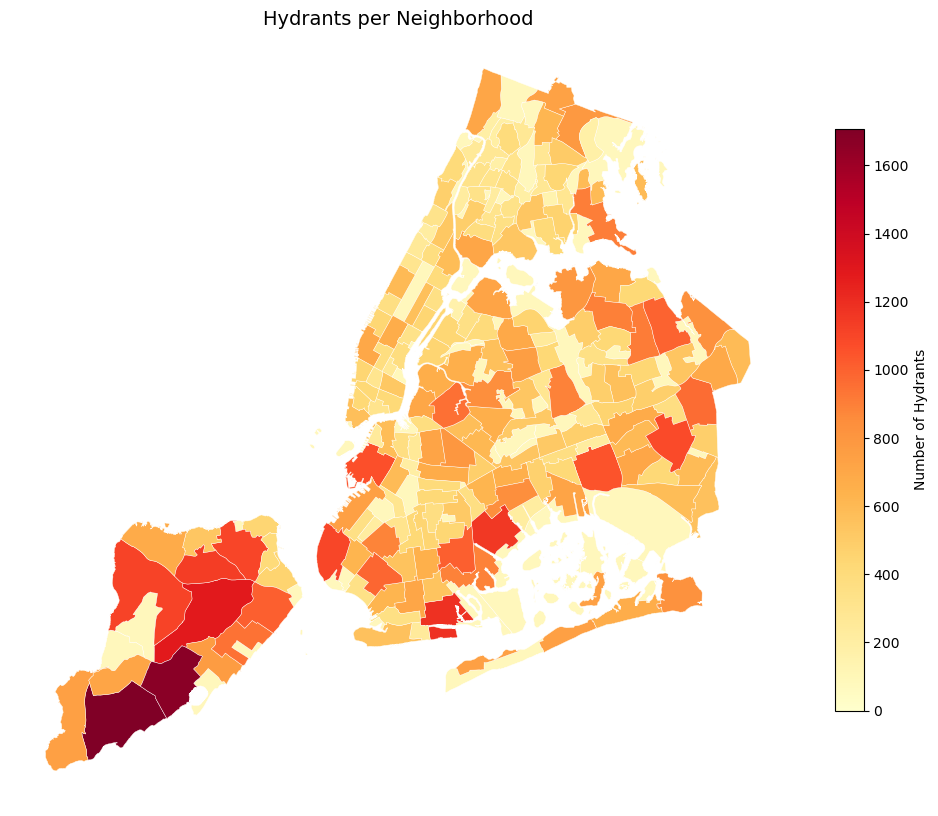

In [12]:
conn = psycopg.connect(
    host=db_host,
    port=db_port,
    dbname=db_name,
    user=db_user,
    password=db_password,
)
print("Connected OK")

# Hydrant counts for choropleth
sql_counts_map = """
SELECT
    n.ntaname,
    n.boroname,
    n.ntatype,
    COUNT(h.id) AS hydrant_count,
    n.geom
FROM nyc_neighborhoods n
LEFT JOIN nyc_hydrants h
    ON ST_Contains(n.geom, h.geom)
WHERE n.ntatype = '0'
GROUP BY n.ntaname, n.boroname, n.ntatype, n.geom;
"""

gdf_counts = gpd.read_postgis(sql_counts_map, conn, geom_col='geom')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1) Plot dummy polygons as base layer
neighborhoods.plot(
    ax=ax,
    color='#fff7bc',          # very light yellow (lowest YlOrRd tone)
    edgecolor='white',
    linewidth=0.3,
    zorder=1,                 # bottom
)

# 2) Plot Chloropleth
gdf_counts.plot(
    ax=ax,
    column='hydrant_count',
    cmap='YlOrRd',
    vmin=0,
    vmax=gdf_counts['hydrant_count'].max(),
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Number of Hydrants', 'shrink': 0.6},
)

ax.set_title('Hydrants per Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


#### 8c. Chloropleth for Hydrant Density by Neighborhood

/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


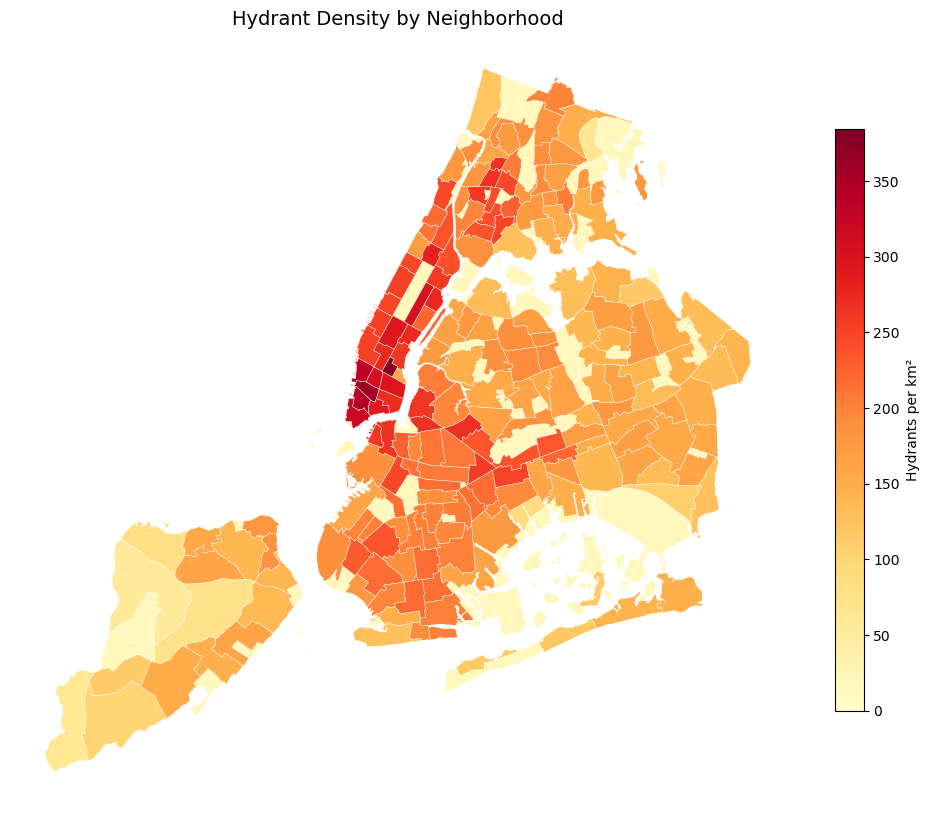

In [13]:
sql_density_map = """
SELECT
    n.boroname,
    n.ntaname,
    n.ntatype,
    COUNT(h.id) AS hydrant_count,
    ROUND(
        (ST_Area(n.geom::geography) / 1000000)::numeric, 2
    ) AS area_km2,
    ROUND(
        COUNT(h.id) / (ST_Area(n.geom::geography) / 1000000)::numeric, 1
    ) AS hydrants_per_km2,
    n.geom
FROM nyc_neighborhoods n
LEFT JOIN nyc_hydrants h
    ON ST_Contains(n.geom, h.geom)
WHERE n.ntatype = '0'
GROUP BY n.boroname, n.ntaname, n.ntatype, n.geom;
"""

gdf_density = gpd.read_postgis(sql_density_map, conn, geom_col='geom')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1) Plot dummy polygons as base layer
neighborhoods.plot(
    ax=ax,
    color='#fff7bc',          # very light yellow (lowest YlOrRd tone)
    edgecolor='white',
    linewidth=0.3,
    zorder=1,                 # bottom
)

# 2) Plot Chloropleth
gdf_density.plot(
    ax=ax,
    column='hydrants_per_km2',
    cmap='YlOrRd',
    vmin=0,
    vmax=gdf_density['hydrants_per_km2'].max(),
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Hydrants per km²', 'shrink': 0.6},
)

ax.set_title('Hydrant Density by Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### 8d. Chloropleth for Percent of Neighborhood with hydrants within 100 m

/Users/pamelagreen/miniforge3/envs/mgis/lib/python3.14/site-packages/geopandas/io/sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


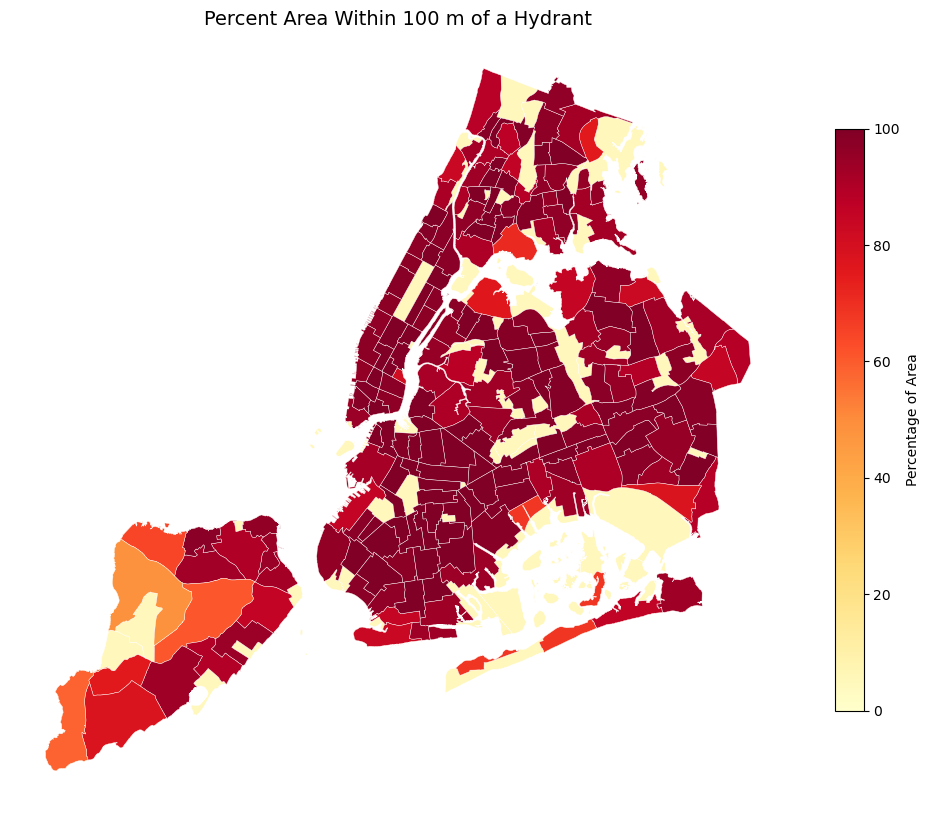

In [14]:
sql_coverage_map = """
WITH coverage AS (
    SELECT geom AS buffer_geom_32618
    FROM nyc_hydrant_coverage_100m
    LIMIT 1
)
SELECT
    n.boroname,
    n.ntaname,
    n.ntatype,
    ROUND(
        COALESCE(
            (
                ST_Area(
                    ST_Intersection(
                        ST_Transform(n.geom, 32618),
                        c.buffer_geom_32618
                    )
                ) / ST_Area(ST_Transform(n.geom, 32618)) * 100
            ),
            0
        )::numeric,
        1
    ) AS percent_covered_100m,
    n.geom
FROM nyc_neighborhoods n
CROSS JOIN coverage c
WHERE n.ntatype = '0';
"""

gdf_coverage = gpd.read_postgis(sql_coverage_map, conn, geom_col='geom')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1) Plot dummy polygons as base layer
neighborhoods.plot(
    ax=ax,
    color='#fff7bc',          # very light yellow (lowest YlOrRd tone)
    edgecolor='white',
    linewidth=0.3,
    zorder=1,                 # bottom
)

# 2) Plot Chloropleth
gdf_coverage.plot(
    ax=ax,
    column='percent_covered_100m',
    cmap='YlOrRd',
    vmin=0,
    vmax=gdf_coverage['percent_covered_100m'].max(),
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Percentage of Area', 'shrink': 0.6},
)

ax.set_title('Percent Area Within 100 m of a Hydrant', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 9. Export Results to GeoParquet

GeoParquet is a modern, efficient format for geospatial data — much faster to read
than Shapefiles or GeoJSON, and it preserves CRS metadata.

In [15]:
output_path = 'data/processed/nyc_neighborhood_hydrant_counts_sql.parquet'

gdf_counts.to_parquet(output_path)

# Verify the export by reading it back
result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"CRS:   {result.crs}")
print(f"Columns: {list(result.columns)}")

output_path = 'data/processed/nyc_neighborhood_hydrant_density_sql.parquet'

gdf_density.to_parquet(output_path)

# Verify the export by reading it back
result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"CRS:   {result.crs}")
print(f"Columns: {list(result.columns)}")

output_path = 'data/processed/nyc_neighborhood_hydrant_coverage_sql.parquet'

gdf_coverage.to_parquet('data/processed/nyc_neighborhood_hydrant_coverage_sql.parquet')

# Verify the export by reading it back
result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"CRS:   {result.crs}")
print(f"Columns: {list(result.columns)}")


Exported to: data/processed/nyc_neighborhood_hydrant_counts_sql.parquet
Shape: (197, 5)
CRS:   {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic lo

## Summary

In this notebook you:

1. Filter. Select all neighborhoods in Manhattan. Sanity check that the data loaded.
2. Spatial join. Use ST_Contains to match each hydrant to the neighborhood that contains it.
3. Aggregate. GROUP BY to count hydrants per neighborhood.
4. Normalize. Add ST_Area(ST_Transform(geom, 2263)) to compute area in square kilometers, then divide count by area to get density per km².
5. Buffer + Union + Intersection. Compute the percent of each neighborhood within 100 meters of a hydrant (coverage analysis).
6. Create chloropleths for neighborhood analysis
7. Exported the results to GeoParquet